# TFTIS Gas-Mixture Dataset and Analysis

This notebook reproduces the feature-extraction and PCA analysis workflow for the initial TFTIS single gas dataset.

The dataset and associated analysis resources are hosted in the public TFTIS GitHub repository:

https://github.com/engrhamzaaliimran/tftis.git

Cloning the dataset

In [1]:
# Clone the TFTIS GitHub repository
!git clone https://github.com/engrhamzaaliimran/tftis.git

fatal: destination path 'tftis' already exists and is not an empty directory.


The subsequent cells extract the 12-dimensional exponentially modified Gaussian (EMG) feature representation from the dense impedance measurements

In [2]:
%%writefile extract_emg12_first35_and_pairwise_pca.py
#!/usr/bin/env python3
"""
Build the same per-sweep, temperature-combined 12-feature EMG table as
EMG_12feat_Combined_AllGases.csv, using only the first 35 sweeps of each H5 file.

For every condition (Sensor, Humidity, Gas, Concentration), sweep i is combined as:
  [EMG at 150C sweep i] + [EMG at 250C sweep i] + [EMG at 350C sweep i]

The EMG model, Z'' computation, initial guesses, bounds, and curve_fit settings are
kept identical to zComplex_EMG_individual_sweeps_data_extraction_robust_v4(2).py.

Outputs:
  EMG_12feat_Combined_First35Sweeps.csv
  PCA_PAIRWISE_PCA_Pairwise_PC1_PC4.png
  PCA_PAIRWISE_PCA_Pairwise_PC1_PC4.eps
  PCA_scores_first35.csv
  pca_explained_variance.csv
  source_file_manifest.csv
  incomplete_or_skipped_conditions.csv
  fit_summary_by_file.csv
"""

import argparse
import hashlib
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
from scipy.special import erfc
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# =============================================================================
# EMG FITTING: COPIED WITHOUT ALGORITHM CHANGES FROM THE PROVIDED EXTRACTOR
# =============================================================================

def emg(x, amp, mu, sigma, lam):
    return amp * (lam / 2) * np.exp((lam / 2) * (2 * mu + lam * sigma**2 - 2 * x)) * \
           erfc((mu + lam * sigma**2 - x) / (np.sqrt(2) * sigma))


def compute_imaginary_impedance(magnitude, phase):
    # phase expected in radians
    return -magnitude * np.sin(phase)


def r2_score(y, yfit):
    ss_res = np.sum((y - yfit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan


def initial_guess_and_bounds(x, y):
    if len(x) == 0 or len(y) == 0 or not np.isfinite(np.nanmax(y)):
        A0 = 1.0
        mu0 = float(np.median(x)) if len(x) else 0.0
    else:
        idx_max = int(np.nanargmax(y))
        Amax = float(np.nanmax(y))
        A0 = Amax if Amax > 0 else 1.0
        mu0 = float(x[idx_max]) if np.isfinite(x[idx_max]) else float(np.nanmedian(x))
    sigma0 = 0.25
    lam0 = 1.0
    x_min = float(np.nanmin(x)) if len(x) else -2.0
    x_max = float(np.nanmax(x)) if len(x) else 8.0
    lower = [0.0, x_min - 1.0, 1e-3, 1e-3]
    amp_upper = (A0 * 10.0) if np.isfinite(A0) and A0 > 0 else 1e6
    upper = [amp_upper, x_max + 1.0, 2.0, 50.0]
    return [A0, mu0, sigma0, lam0], (lower, upper)


def fit_emg_single_sweep(freq_1d, z_imag_1d):
    mask = np.isfinite(freq_1d) & (freq_1d > 0) & np.isfinite(z_imag_1d)
    x = np.log10(freq_1d[mask])
    y = z_imag_1d[mask]
    if len(x) < 10 or not np.isfinite(np.nanmax(y)) or np.nanmax(y) <= 0:
        return (False, *(np.nan,)*4, np.nan)
    p0, bounds = initial_guess_and_bounds(x, y)
    try:
        popt, _ = curve_fit(emg, x, y, p0=p0, bounds=bounds, maxfev=20000)
        yfit = emg(x, *popt)
        return (True, float(popt[0]), float(popt[1]), float(popt[2]), float(popt[3]), r2_score(y, yfit))
    except Exception:
        return (False, *(np.nan,)*4, np.nan)


def load_impedance_data(path: str):
    with h5py.File(path, "r") as f:
        freq = f["frequency"][()]
        mag = f["magnitude"][()]
        phase = f["phase"][()]
    return freq, mag, phase


# =============================================================================
# METADATA + FILE COLLECTION
# =============================================================================

TEMP_RE = re.compile(r"(?<!\d)(150|250|350)\s*C", re.IGNORECASE)
RH_RE = re.compile(r"(?<!\d)(\d+)\s*RH", re.IGNORECASE)
CONC_RE = re.compile(r"(?<!\d)(\d+(?:\.\d+)?)\s*(ppb|ppm)", re.IGNORECASE)


def normalise_gas(gas: str) -> str:
    """Keep labels compatible with the supplied 12-feature reference table."""
    g = str(gas).strip().lower().replace("-", "").replace("_", "")
    aliases = {
        "h2": "Hydrogen",
        "hydrogen": "Hydrogen",
        "zeroair": "ZeroAir",
        "zero": "ZeroAir",
        "ethanol": "Ethanol",
        "acetone": "Acetone",
        "methanol": "Methanol",
        "co": "CO",
        "carbonmonoxide": "CO",
    }
    return aliases.get(g, str(gas).strip())


def clean_concentration(value: float, unit: str) -> Tuple[str, float]:
    """Returns the label used by the reference CSV, e.g. '3ppm' or '4000ppb'."""
    if float(value).is_integer():
        value_s = str(int(value))
    else:
        value_s = (f"{value:.12g}").rstrip("0").rstrip(".")
    label = f"{value_s}{unit.lower()}"
    ppb = float(value) * 1000.0 if unit.lower() == "ppm" else float(value)
    return label, ppb


def metadata_from_file(h5_path: Path) -> Dict[str, object]:
    """
    Parse metadata. Curated directory labels are preferred for gas/RH/temp because
    they remain valid for names containing an inserted 'ShortSweep' token.
    """
    name = h5_path.name
    parts = list(h5_path.parts)

    # Curated folders: Gas_Ethanol / RH_50 / Temp_150C
    gas_folder = next((p[4:] for p in parts if p.lower().startswith("gas_")), None)
    rh_folder = next((p[3:] for p in parts if p.lower().startswith("rh_")), None)
    temp_folder = next((p[5:] for p in parts if p.lower().startswith("temp_")), None)

    temp_match = TEMP_RE.search(temp_folder or name)
    rh_match = RH_RE.search((rh_folder or "") + "RH") if rh_folder else RH_RE.search(name)
    conc_match = CONC_RE.search(name)

    if not temp_match:
        raise ValueError(f"Could not parse temperature (150C/250C/350C): {name}")
    if not rh_match:
        raise ValueError(f"Could not parse RH: {name}")
    if not conc_match:
        raise ValueError(f"Could not parse concentration: {name}")

    temp_c = int(temp_match.group(1))
    humidity = f"{int(rh_match.group(1))}RH"
    concentration, concentration_ppb = clean_concentration(
        float(conc_match.group(1)), conc_match.group(2)
    )

    # In curated folders this is definitive. Fallback: token immediately before concentration.
    if gas_folder:
        gas = normalise_gas(gas_folder)
    else:
        norm = re.sub(r"[ _]+", "-", name)
        tokens = [t for t in re.split(r"[-]+", norm) if t]
        conc_token_idx = next(
            (i for i, t in enumerate(tokens) if CONC_RE.fullmatch(t)), None
        )
        if conc_token_idx is None or conc_token_idx == 0:
            raise ValueError(f"Could not infer gas from filename: {name}")
        gas = normalise_gas(tokens[conc_token_idx - 1])

    # Sensor is the tokens after the temperature token and before RH.
    # Example: 150C-MLV-P2-50RH-... -> MLV-P2
    norm = re.sub(r"[ _]+", "-", name)
    tokens = [t for t in re.split(r"[-]+", norm) if t]
    t_idx = next((i for i, t in enumerate(tokens) if TEMP_RE.fullmatch(t)), None)
    r_idx = next((i for i, t in enumerate(tokens) if RH_RE.fullmatch(t)), None)
    sensor = "UnknownSensor"
    if t_idx is not None and r_idx is not None and r_idx > t_idx + 1:
        sensor = "-".join(tokens[t_idx + 1:r_idx])

    return {
        "Temperature": f"{temp_c}C",
        "TempC": temp_c,
        "Humidity": humidity,
        "Sensor": sensor,
        "Gas": gas,
        "Concentration": concentration,
        "Concentration_label": concentration,
        "Concentration_ppb": concentration_ppb,
    }


def choose_one_file(candidates: List[Path]) -> Path:
    """
    A curated folder normally has one file per condition/temperature. If a copied
    duplicate exists, prefer the original filename over the collision-renamed copy
    ending in '__<hash>.h5'. The other candidates are recorded in the manifest.
    """
    def priority(p: Path):
        collision_copy = bool(re.search(r"__[0-9a-f]{8,}\.(?:h5|hdf5)$", p.name, flags=re.I))
        return (collision_copy, p.name.lower())
    return sorted(candidates, key=priority)[0]


def collect_selected_files(input_dir: Path) -> Tuple[List[Dict[str, object]], List[Dict[str, object]]]:
    h5_files = sorted(list(input_dir.rglob("*.h5")) + list(input_dir.rglob("*.H5")))
    if not h5_files:
        raise FileNotFoundError(f"No .h5 files found recursively below: {input_dir}")

    grouped: Dict[Tuple[str, str, str, str, int], List[Tuple[Path, Dict[str, object]]]] = {}
    skipped: List[Dict[str, object]] = []

    for p in h5_files:
        try:
            meta = metadata_from_file(p)
            key = (meta["Sensor"], meta["Humidity"], meta["Gas"], meta["Concentration"], meta["TempC"])
            grouped.setdefault(key, []).append((p, meta))
        except Exception as exc:
            skipped.append({"Status": "metadata_parse_failed", "Path": str(p), "Reason": str(exc)})

    selected: List[Dict[str, object]] = []
    for key, items in grouped.items():
        candidate_paths = [p for p, _ in items]
        selected_path = choose_one_file(candidate_paths)
        selected_meta = next(meta for p, meta in items if p == selected_path)
        selected.append({
            **selected_meta,
            "Path": str(selected_path),
            "DuplicateCandidates": ";".join(str(p) for p in candidate_paths),
            "NumCandidates": len(candidate_paths),
        })

    return selected, skipped


# =============================================================================
# EMG EXTRACTION + 12D COMBINATION
# =============================================================================

PARAM_COLS = ["Amplitude", "Mu (log10 Hz)", "Sigma", "Lambda"]
TEMPS = (150, 250, 350)
FEATURE_COLS_12 = [f"{param}_{temp}C" for temp in TEMPS for param in PARAM_COLS]


def extract_file_first_sweeps(record: Dict[str, object], max_sweeps: int) -> Tuple[pd.DataFrame, Dict[str, object]]:
    path = str(record["Path"])
    freq, mag, phase = load_impedance_data(path)
    if freq.ndim == 1:
        freq = freq[None, :]
        mag = mag[None, :]
        phase = phase[None, :]

    zim = compute_imaginary_impedance(mag, phase)
    n_available = int(zim.shape[0])
    n_use = min(int(max_sweeps), n_available)
    rows = []

    for sweep_idx in range(n_use):
        ok, amp, mu, sigma, lam, r2 = fit_emg_single_sweep(freq[sweep_idx], zim[sweep_idx])
        rows.append({
            "Path": path,
            "Filename": Path(path).name,
            "TempC": int(record["TempC"]),
            "Temperature": record["Temperature"],
            "Humidity": record["Humidity"],
            "Sensor": record["Sensor"],
            "Gas": record["Gas"],
            "Concentration": record["Concentration"],
            "Concentration_label": record["Concentration_label"],
            "Concentration_ppb": record["Concentration_ppb"],
            "SweepID": sweep_idx,
            "Amplitude": amp,
            "Mu (log10 Hz)": mu,
            "Sigma": sigma,
            "Lambda": lam,
            "R2": r2,
            "FitSuccess": bool(ok),
        })

    file_summary = {
        "Path": path,
        "Filename": Path(path).name,
        "Sensor": record["Sensor"],
        "Humidity": record["Humidity"],
        "Gas": record["Gas"],
        "Concentration": record["Concentration"],
        "Temperature": record["Temperature"],
        "SweepsAvailable": n_available,
        "SweepsRequested": int(max_sweeps),
        "SweepsProcessed": n_use,
        "SuccessfulFits": int(sum(r["FitSuccess"] for r in rows)),
        "FitSuccessRate": float(np.mean([r["FitSuccess"] for r in rows])) if rows else np.nan,
    }
    return pd.DataFrame(rows), file_summary


def combine_to_12d(df_sweep: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Inner-join successful sweep i values across 150C, 250C, and 350C."""
    condition_cols = ["Sensor", "Humidity", "Gas", "Concentration", "Concentration_label", "Concentration_ppb"]
    manifests = []
    combined_blocks = []

    for condition, dcond in df_sweep.groupby(condition_cols, dropna=False, sort=True):
        condition_info = dict(zip(condition_cols, condition))
        temp_frames = {}
        status = "complete"
        reason = ""

        for temp in TEMPS:
            dt = dcond[dcond["TempC"] == temp].copy()
            if dt.empty:
                status = "skipped"
                reason = f"missing_{temp}C_file"
                break

            good = dt[dt["FitSuccess"]].copy()
            if good.empty:
                status = "skipped"
                reason = f"no_successful_fits_{temp}C"
                break

            good = good.set_index("SweepID")[PARAM_COLS]
            good = good.rename(columns={p: f"{p}_{temp}C" for p in PARAM_COLS})
            temp_frames[temp] = good

        if status == "complete":
            merged = temp_frames[150].join(temp_frames[250], how="inner").join(temp_frames[350], how="inner")
            if merged.empty:
                status = "skipped"
                reason = "no_common_successful_sweep_ids_across_150_250_350C"
            else:
                merged = merged.reset_index()
                for col, value in condition_info.items():
                    merged[col] = value
                # Reference layout first, then required identifiers for RH/sensor.
                ordered = [
                    "Gas", "Concentration", "Concentration_label", "SweepID",
                    "Humidity", "Sensor", "Concentration_ppb",
                ] + FEATURE_COLS_12
                merged = merged[ordered]
                combined_blocks.append(merged)

        manifests.append({
            **condition_info,
            "Status": status,
            "Reason": reason,
            "CombinedRows": 0 if status != "complete" else len(merged),
            "Successful150C": int(dcond[(dcond["TempC"] == 150) & dcond["FitSuccess"]].shape[0]),
            "Successful250C": int(dcond[(dcond["TempC"] == 250) & dcond["FitSuccess"]].shape[0]),
            "Successful350C": int(dcond[(dcond["TempC"] == 350) & dcond["FitSuccess"]].shape[0]),
        })

    df12 = pd.concat(combined_blocks, ignore_index=True) if combined_blocks else pd.DataFrame()
    df_manifest = pd.DataFrame(manifests)
    return df12, df_manifest


# =============================================================================
# PCA: 4 PCS + SIX PAIRWISE PANELS, AS IN THE REFERENCE EPS FIGURE
# =============================================================================

def concentration_to_ppm(values: pd.Series) -> np.ndarray:
    return pd.to_numeric(values, errors="coerce").to_numpy(dtype=float) / 1000.0


def shade_colors(base_cmap, concentration_ppb: np.ndarray) -> np.ndarray:
    finite = np.isfinite(concentration_ppb)
    if not np.any(finite) or np.nanmax(concentration_ppb[finite]) == np.nanmin(concentration_ppb[finite]):
        t = np.full(len(concentration_ppb), 0.65)
    else:
        lo, hi = np.nanmin(concentration_ppb[finite]), np.nanmax(concentration_ppb[finite])
        t = 0.35 + 0.60 * (concentration_ppb - lo) / (hi - lo)
        t = np.nan_to_num(t, nan=0.65)
        t = np.clip(t, 0.35, 0.95)
    return base_cmap(t)


def assign_pca_groups(df: pd.DataFrame) -> pd.Series:
    """
    Same intended split as the previous analysis pipeline:
      - training: Acetone + Ethanol + Hydrogen at 50RH,
        except ethanol 3 and 6 ppm, which are inference/test points;
      - Hydrogen at 90RH and all ZeroAir are test/inference points.
    """
    gas = df["Gas"].astype(str)
    rh = df["Humidity"].astype(str)
    conc_ppb = pd.to_numeric(df["Concentration_ppb"], errors="coerce")

    group = pd.Series("Other_test", index=df.index, dtype=object)
    group[(gas == "Acetone") & (rh == "50RH")] = "Acetone_train"
    group[(gas == "Ethanol") & (rh == "50RH")] = "Ethanol_train"
    group[(gas == "Hydrogen") & (rh == "50RH")] = "Hydrogen_train"

    group[(gas == "Ethanol") & (rh == "50RH") & (conc_ppb == 3000.0)] = "Ethanol_3ppm_test"
    group[(gas == "Ethanol") & (rh == "50RH") & (conc_ppb == 6000.0)] = "Ethanol_6ppm_test"
    group[(gas == "Hydrogen") & (rh == "90RH")] = "Hydrogen_90RH_test"
    group[(gas == "ZeroAir") & (rh == "50RH")] = "ZeroAir_50RH_test"
    group[(gas == "ZeroAir") & (rh == "80RH")] = "ZeroAir_80RH_test"
    return group


def save_pairwise_pca(df12: pd.DataFrame, outdir: Path) -> None:
    clean = df12.dropna(subset=FEATURE_COLS_12).copy()
    if len(clean) < 5:
        raise RuntimeError("Need at least five complete 12D rows for PCA.")

    clean["PCA_Group"] = assign_pca_groups(clean)
    is_train = clean["PCA_Group"].str.endswith("_train").to_numpy()
    if int(is_train.sum()) < 4:
        raise RuntimeError("Need at least four training rows to compute four PCA components.")

    scaler = StandardScaler()
    X_train = scaler.fit_transform(clean.loc[is_train, FEATURE_COLS_12].to_numpy(dtype=float))
    X_all = scaler.transform(clean[FEATURE_COLS_12].to_numpy(dtype=float))

    pca = PCA(n_components=4, random_state=42)
    pca.fit(X_train)
    scores = pca.transform(X_all)

    score_df = clean.copy()
    for i in range(4):
        score_df[f"PC{i+1}"] = scores[:, i]
    score_df.to_csv(outdir / "PCA_scores_first35.csv", index=False)

    evr = pca.explained_variance_ratio_
    pd.DataFrame({
        "Component": [f"PC{i+1}" for i in range(4)],
        "ExplainedVarianceRatio": evr,
        "ExplainedVariancePercent": evr * 100.0,
    }).to_csv(outdir / "pca_explained_variance.csv", index=False)

    # Style intentionally follows the provided pairwise PCA reference.
    styles = {
        "Acetone_train": {"marker": "o", "cmap": plt.cm.Oranges, "edge": "black", "face": "auto", "label": "Acetone"},
        "Ethanol_train": {"marker": "s", "cmap": plt.cm.Blues, "edge": "black", "face": "auto", "label": "Ethanol"},
        "Hydrogen_train": {"marker": "^", "cmap": plt.cm.Greens, "edge": "black", "face": "auto", "label": "Hydrogen"},
        "Ethanol_3ppm_test": {"marker": "s", "cmap": None, "edge": "#e7298a", "face": "none", "label": "Ethanol 3 ppm test"},
        "Ethanol_6ppm_test": {"marker": "s", "cmap": None, "edge": "#e7298a", "face": "none", "label": "Ethanol 6 ppm test"},
        "Hydrogen_90RH_test": {"marker": "^", "cmap": None, "edge": "#7b3294", "face": "none", "label": "Hydrogen 90%RH test"},
        "ZeroAir_50RH_test": {"marker": "P", "cmap": None, "edge": "0.20", "face": "0.72", "label": "ZeroAir 50%RH"},
        "ZeroAir_80RH_test": {"marker": "X", "cmap": None, "edge": "0.20", "face": "0.72", "label": "ZeroAir 80%RH"},
        "Other_test": {"marker": "D", "cmap": None, "edge": "0.15", "face": "0.75", "label": "Other test"},
    }

    pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
    fig, axes = plt.subplots(2, 3, figsize=(12.8, 7.8), constrained_layout=True)

    for ax, (x_i, y_i) in zip(axes.ravel(), pairs):
        for group_name in [
            "Acetone_train", "Ethanol_train", "Hydrogen_train",
            "Ethanol_3ppm_test", "Ethanol_6ppm_test", "Hydrogen_90RH_test",
            "ZeroAir_50RH_test", "ZeroAir_80RH_test", "Other_test",
        ]:
            mask = score_df["PCA_Group"].eq(group_name).to_numpy()
            if not np.any(mask):
                continue
            st = styles[group_name]
            if st["face"] == "auto":
                c = shade_colors(st["cmap"], score_df.loc[mask, "Concentration_ppb"].to_numpy(dtype=float))
                ax.scatter(scores[mask, x_i], scores[mask, y_i],
                           c=c, marker=st["marker"], s=42,
                           edgecolors=st["edge"], linewidths=0.65, zorder=3)
            else:
                ax.scatter(scores[mask, x_i], scores[mask, y_i],
                           marker=st["marker"], s=55,
                           facecolors=st["face"], edgecolors=st["edge"],
                           linewidths=1.15, zorder=4)

        ax.set_title(f"PC{x_i+1} vs PC{y_i+1}")
        ax.set_xlabel(f"PC{x_i+1} ({evr[x_i] * 100:.1f}%)")
        ax.set_ylabel(f"PC{y_i+1} ({evr[y_i] * 100:.1f}%)")
        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    train_handles = [
        Line2D([0], [0], marker="o", linestyle="", markerfacecolor=plt.cm.Oranges(0.65), markeredgecolor="black", label="Acetone"),
        Line2D([0], [0], marker="s", linestyle="", markerfacecolor=plt.cm.Blues(0.65), markeredgecolor="black", label="Ethanol"),
        Line2D([0], [0], marker="^", linestyle="", markerfacecolor=plt.cm.Greens(0.65), markeredgecolor="black", label="Hydrogen"),
    ]
    test_handles = []
    for group_name in [
        "Ethanol_3ppm_test", "Ethanol_6ppm_test", "Hydrogen_90RH_test",
        "ZeroAir_50RH_test", "ZeroAir_80RH_test", "Other_test",
    ]:
        if not score_df["PCA_Group"].eq(group_name).any():
            continue
        st = styles[group_name]
        test_handles.append(Line2D([0], [0], marker=st["marker"], linestyle="",
                                   markerfacecolor=st["face"], markeredgecolor=st["edge"],
                                   markeredgewidth=1.1, label=st["label"]))

    fig.legend(handles=train_handles, title="Training gases", loc="upper left",
               bbox_to_anchor=(0.01, 1.02), frameon=False)
    if test_handles:
        fig.legend(handles=test_handles, title="Test / inference conditions", loc="upper right",
                   bbox_to_anchor=(0.99, 1.02), frameon=False, ncol=min(3, len(test_handles)))

    fig.suptitle(
        "Pairwise PCA of 12 EMG Features (first 35 sweeps)\n"
        + "  |  ".join(f"PC{i+1}: {evr[i] * 100:.1f}%" for i in range(4)),
        y=1.10, fontsize=12
    )

    png_path = outdir / "PCA_PAIRWISE_PCA_Pairwise_PC1_PC4.png"
    eps_path = outdir / "PCA_PAIRWISE_PCA_Pairwise_PC1_PC4.eps"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(eps_path, format="eps", bbox_inches="tight")
    plt.close(fig)


# =============================================================================
# MAIN
# =============================================================================

def main():
    ap = argparse.ArgumentParser(
        description="Create a 12-feature EMG table by aligning the first 35 sweeps across 150C/250C/350C, then create pairwise PCA PC1–PC4."
    )
    ap.add_argument("--input_dir", required=True, help="Curated H5 root directory. All .h5 files are found recursively.")
    ap.add_argument("--outdir", default="emg12_first35_results", help="Directory for CSV and PCA outputs.")
    ap.add_argument("--max_sweeps", type=int, default=35, help="Number of earliest sweeps per H5 to use. Default: 35.")
    ap.add_argument("--workers", type=int, default=min(4, os.cpu_count() or 1),
                    help="Parallel H5 workers. EMG fitting algorithm is unchanged. Default: up to 4 CPU cores.")
    args = ap.parse_args()

    if args.max_sweeps <= 0:
        ap.error("--max_sweeps must be at least 1.")
    if args.workers <= 0:
        ap.error("--workers must be at least 1.")

    input_dir = Path(args.input_dir).expanduser().resolve()
    outdir = Path(args.outdir).expanduser().resolve()
    if not input_dir.is_dir():
        raise NotADirectoryError(f"Not a directory: {input_dir}")
    outdir.mkdir(parents=True, exist_ok=True)

    print(f"[INFO] Input directory: {input_dir}")
    print(f"[INFO] Using only sweeps 0 to {args.max_sweeps - 1} from each H5 file.")
    print(f"[INFO] Parallel workers: {args.workers}")

    selected_files, parse_skips = collect_selected_files(input_dir)
    print(f"[INFO] Selected condition/temperature files: {len(selected_files)}")

    source_manifest = pd.DataFrame(selected_files)
    source_manifest.to_csv(outdir / "source_file_manifest.csv", index=False)

    file_rows = []
    file_summaries = []
    extraction_failures = list(parse_skips)

    # Each H5 file is independent. Parallelism changes only run time; every file
    # still uses the identical EMG fitting routine above.
    completed = 0
    with ProcessPoolExecutor(max_workers=args.workers) as executor:
        future_to_record = {
            executor.submit(extract_file_first_sweeps, record, args.max_sweeps): record
            for record in selected_files
        }
        for future in as_completed(future_to_record):
            record = future_to_record[future]
            try:
                df_one, summary = future.result()
                file_rows.append(df_one)
                file_summaries.append(summary)
            except Exception as exc:
                extraction_failures.append({
                    "Status": "h5_processing_failed", "Path": record["Path"], "Reason": str(exc)
                })
            completed += 1
            if completed % 10 == 0 or completed == len(selected_files):
                print(f"[INFO] Processed {completed}/{len(selected_files)} H5 files")

    if not file_rows:
        raise RuntimeError("No H5 file could be processed successfully.")

    df_sweeps = pd.concat(file_rows, ignore_index=True)
    pd.DataFrame(file_summaries).to_csv(outdir / "fit_summary_by_file.csv", index=False)

    df12, condition_manifest = combine_to_12d(df_sweeps)
    if df12.empty:
        raise RuntimeError("No complete 150C/250C/350C, successful-fit sweep triplets were produced.")

    # Exact reference feature names are retained. Humidity/Sensor are kept as extra
    # identity columns because this curated set contains multiple RH domains/sensors.
    combined_path = outdir / "EMG_12feat_Combined_First35Sweeps.csv"
    df12.to_csv(combined_path, index=False)

    if extraction_failures:
        failure_df = pd.DataFrame(extraction_failures)
    else:
        failure_df = pd.DataFrame(columns=["Status", "Path", "Reason"])
    condition_manifest.to_csv(outdir / "condition_merge_manifest.csv", index=False)
    failure_df.to_csv(outdir / "incomplete_or_skipped_conditions.csv", index=False)

    save_pairwise_pca(df12, outdir)

    n_conditions = df12[["Sensor", "Humidity", "Gas", "Concentration"]].drop_duplicates().shape[0]
    print("\n[DONE]")
    print(f"[DONE] 12D rows: {len(df12)}")
    print(f"[DONE] Complete conditions: {n_conditions}")
    print(f"[DONE] Feature CSV: {combined_path}")
    print(f"[DONE] PCA PNG: {outdir / 'PCA_PAIRWISE_PCA_Pairwise_PC1_PC4.png'}")
    print(f"[DONE] PCA EPS: {outdir / 'PCA_PAIRWISE_PCA_Pairwise_PC1_PC4.eps'}")


if __name__ == "__main__":
    main()


Writing extract_emg12_first35_and_pairwise_pca.py


In [7]:
!ls tftis/single-gas-data

Gas_Acetone  Gas_Ethanol  Gas_H2  Gas_ZeroAir  README.md


In [8]:
!python extract_emg12_first35_and_pairwise_pca.py   --input_dir tftis/single-gas-data/   --outdir emg12_first35_results   --workers 4

[INFO] Input directory: /content/tftis/single-gas-data
[INFO] Using only sweeps 0 to 34 from each H5 file.
[INFO] Parallel workers: 4
[INFO] Selected condition/temperature files: 99
/content/extract_emg12_first35_and_pairwise_pca.py:47: RuntimeWarning: overflow encountered in exp
  return amp * (lam / 2) * np.exp((lam / 2) * (2 * mu + lam * sigma**2 - 2 * x)) * \
/content/extract_emg12_first35_and_pairwise_pca.py:47: RuntimeWarning: overflow encountered in multiply
  return amp * (lam / 2) * np.exp((lam / 2) * (2 * mu + lam * sigma**2 - 2 * x)) * \
/content/extract_emg12_first35_and_pairwise_pca.py:47: RuntimeWarning: invalid value encountered in multiply
  return amp * (lam / 2) * np.exp((lam / 2) * (2 * mu + lam * sigma**2 - 2 * x)) * \
/content/extract_emg12_first35_and_pairwise_pca.py:47: RuntimeWarning: overflow encountered in exp
  return amp * (lam / 2) * np.exp((lam / 2) * (2 * mu + lam * sigma**2 - 2 * x)) * \
/content/extract_emg12_first35_and_pairwise_pca.py:47: RuntimeWarni

The following cells, generate the PCA visualization

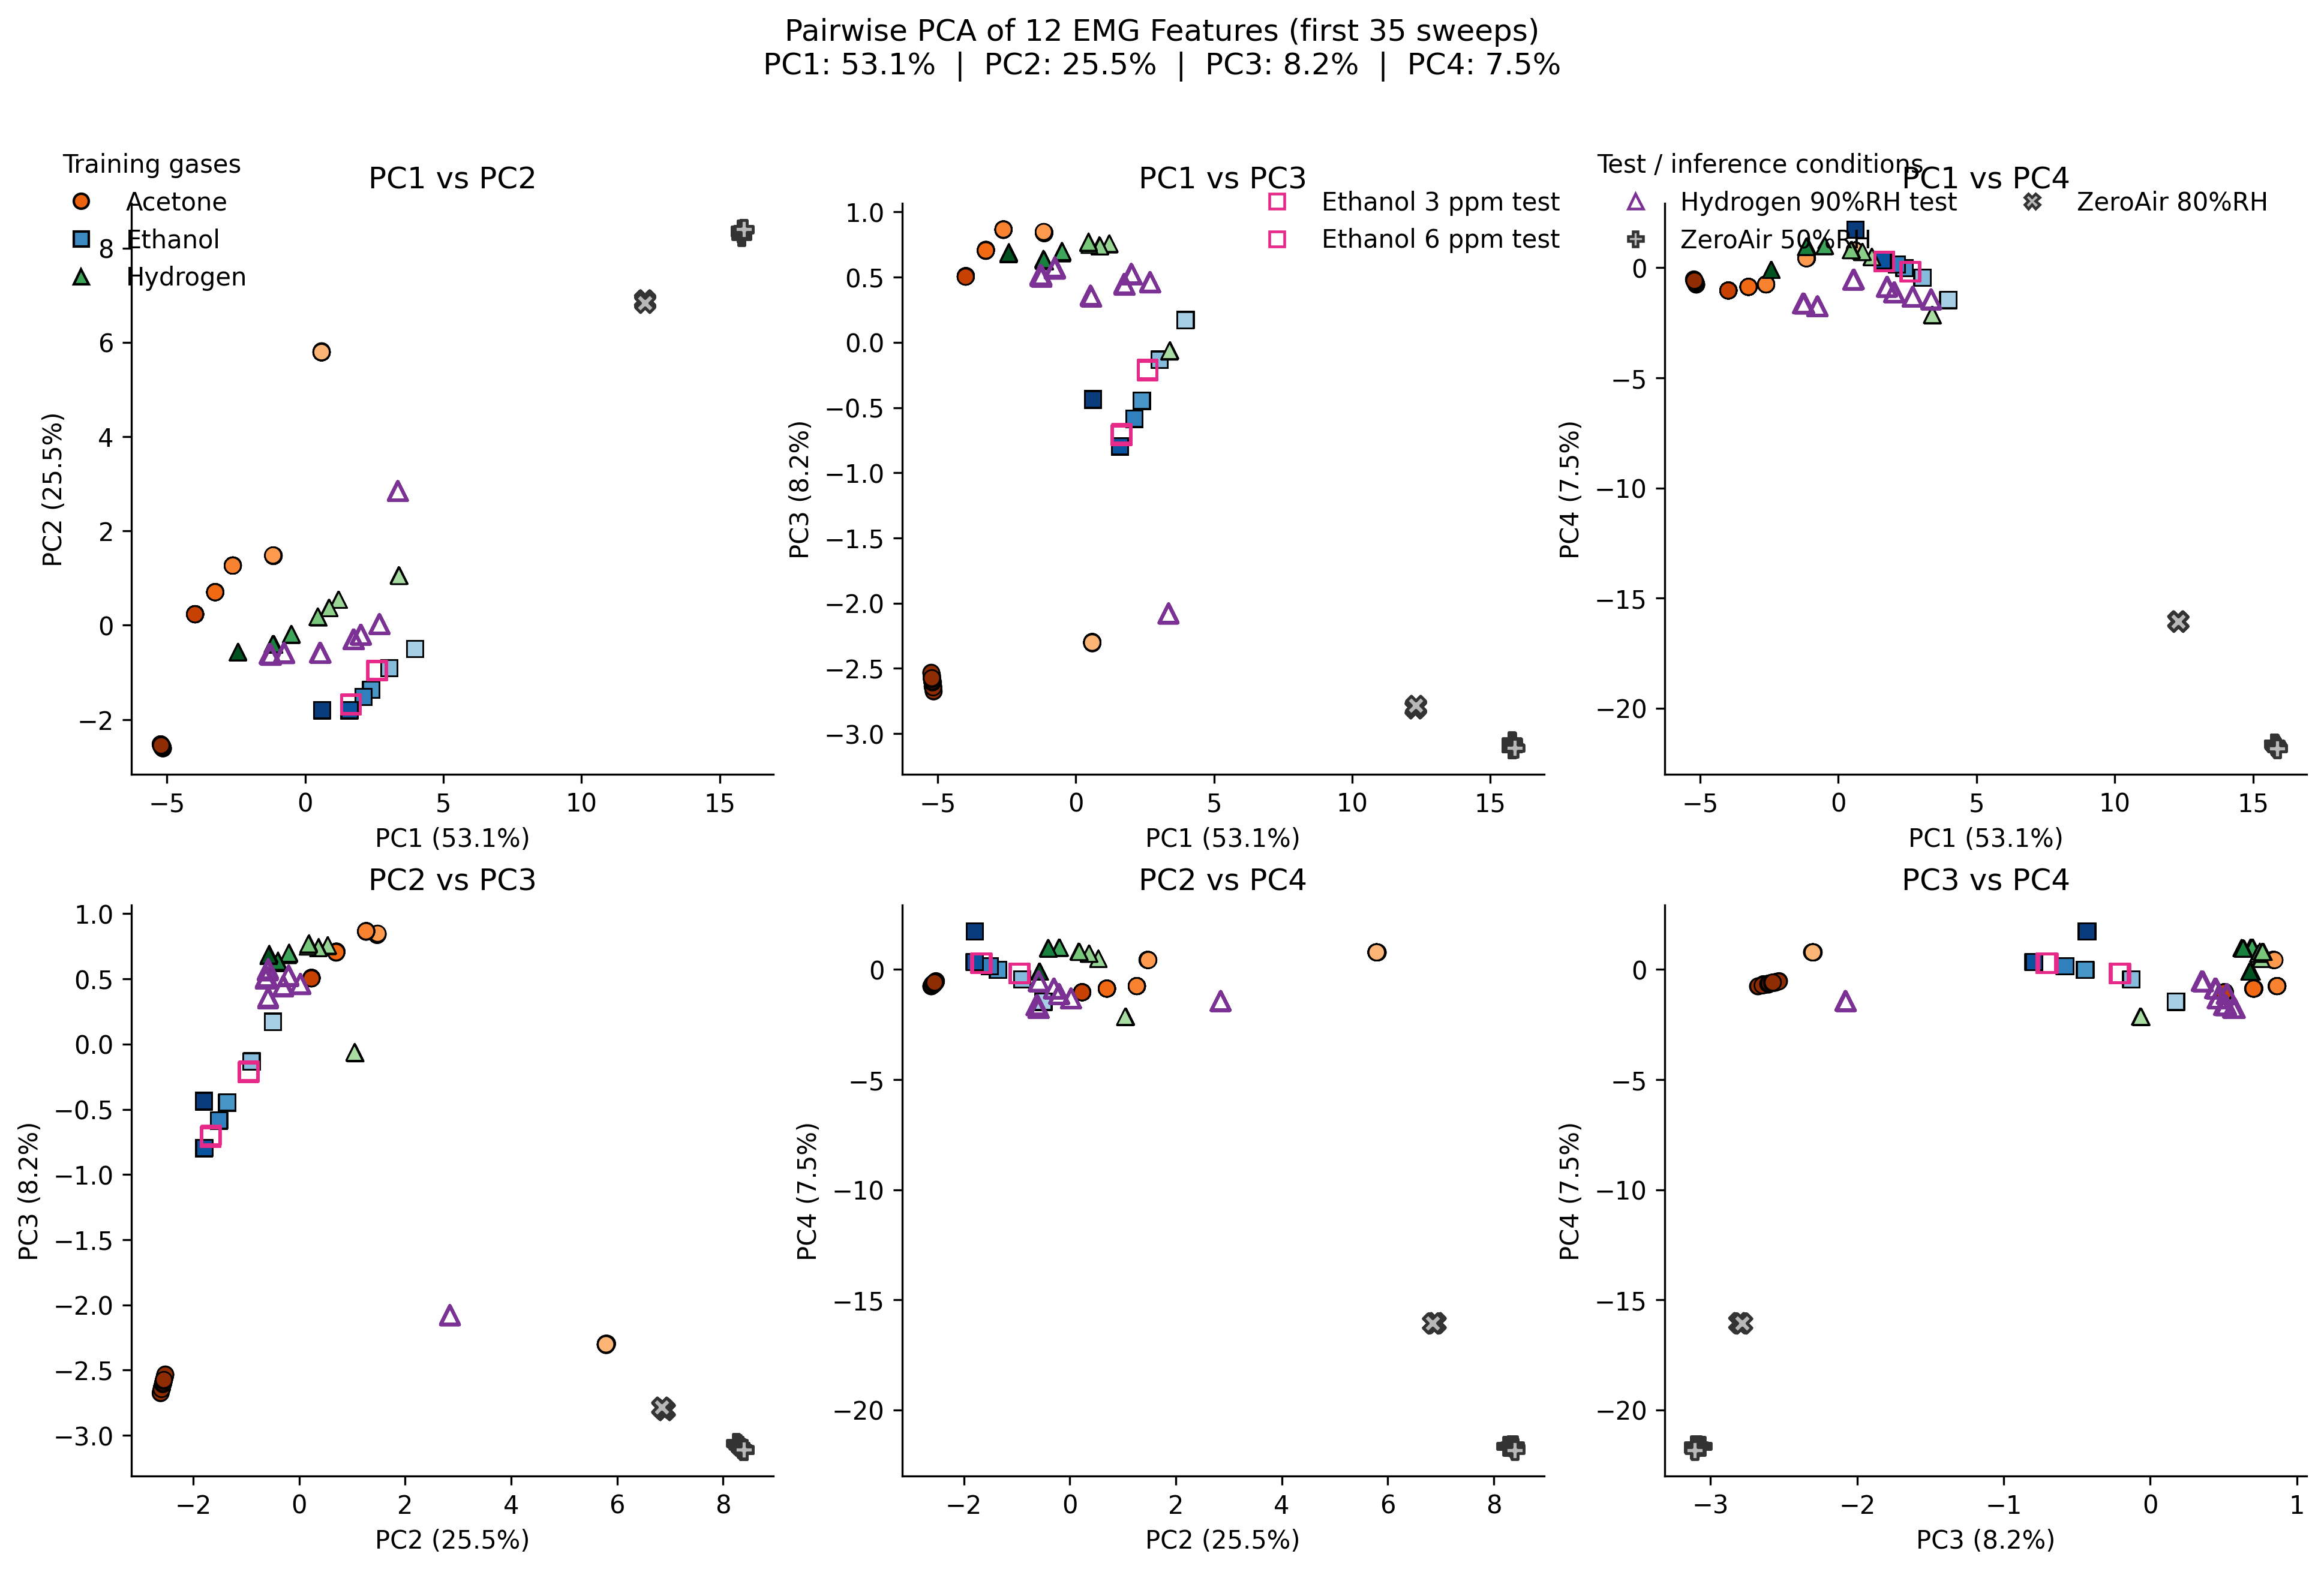

In [9]:
from IPython.display import Image, display

display(Image(filename="/content/emg12_first35_results/PCA_PAIRWISE_PCA_Pairwise_PC1_PC4.png"))